In [1]:
import os
import sys
import re
import tqdm
from pathlib import Path
from dotenv import load_dotenv
import supervision as sv
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

load_dotenv('.env')
DIR_SRC = os.getenv('DIR_SRC')
dir_s1 = Path("out") / "study2"
ls_meta = [f for f in dir_s1.iterdir() if f.suffix == '.csv' and f.name.startswith('results_')]
ls_meta

[PosixPath('out/study2/results_5.csv'),
 PosixPath('out/study2/results_3.csv'),
 PosixPath('out/study2/results_1.csv'),
 PosixPath('out/study2/results_6.csv'),
 PosixPath('out/study2/results_9.csv'),
 PosixPath('out/study2/results_0.csv'),
 PosixPath('out/study2/results_2.csv'),
 PosixPath('out/study2/results_4.csv'),
 PosixPath('out/study2/results_8.csv'),
 PosixPath('out/study2/results_7.csv')]

In [2]:
data = pd.read_csv(ls_meta[0])
for i in range(1, len(ls_meta)):
    data_tmp = pd.read_csv(ls_meta[i])
    data = pd.concat([data, data_tmp])
print(data.columns)
data
# study1: n (5) x split (6) x rep (20) = 600
# study2: model (5) x split (6) = 30
# total: 630

Index(['model', 'n_params', 'is_finetune', 'thread', 'iters', 'metric',
       'strategy', 'time_hptuning', 'time_inference', 'divider', 'overlap',
       'map5095', 'map50', 'precision', 'recall', 'f1', 'n_all', 'n_fn',
       'n_fp'],
      dtype='object')


,model,n_params,is_finetune,thread,iters,metric,strategy,time_hptuning,time_inference,divider,overlap,map5095,map50,precision,recall,f1,n_all,n_fn,n_fp
0,yolo11n,2.6,2_FT,5,1,baseline,baseline,0.00,4.80,0.0,0.00,0.0001,0.0009,0.0019,0.0001,0.0002,81966,81958,4278
1,yolo11n,2.6,2_FT,5,1,count,bo_exploration,5.55,94.94,3.0,0.49,0.3686,0.6954,0.7795,0.6535,0.7110,81966,28399,15150
2,yolo11n,2.6,2_FT,5,1,count,bo_exploitation,1.19,10.55,1.0,0.28,0.0043,0.0207,0.0410,0.0066,0.0114,81966,81422,12714
3,yolo11n,2.6,2_FT,5,1,count,grid_search,8.02,129.72,4.0,0.50,0.4276,0.7283,0.8092,0.6935,0.7469,81966,25122,13399
4,yolo11n,2.6,2_FT,5,1,map,bo_exploration,10.49,44.20,2.0,0.13,0.2340,0.5249,0.6652,0.4581,0.5426,81966,44415,18900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,yolo11n,2.6,2_FT,7,2,count,bo_exploitation,3.44,57.70,3.0,0.25,0.4217,0.7364,0.8119,0.6772,0.7385,82784,26720,12991
25,yolo11n,2.6,2_FT,7,2,count,grid_search,5.65,122.48,4.0,0.50,0.4473,0.7628,0.8324,0.7082,0.7653,82784,24156,11807
26,yolo11n,2.6,2_FT,7,2,map,bo_exploration,6.07,67.13,3.0,0.31,0.4034,0.7308,0.8143,0.6695,0.7348,82784,27363,12639
27,yolo11n,2.6,2_FT,7,2,map,bo_exploitation,6.47,110.06,4.0,0.41,0.4430,0.7613,0.8339,0.7055,0.7644,82784,24378,11632


In [3]:
# calculate mean, median, std, min, max
data_sum = data.groupby(['model', 'is_finetune', "metric", "strategy"]).agg(
    pre_mean=pd.NamedAgg(column='precision', aggfunc='mean'),
    pre_median=pd.NamedAgg(column='precision', aggfunc='median'),
    pre_std=pd.NamedAgg(column='precision', aggfunc='std'),
    pre_min=pd.NamedAgg(column='precision', aggfunc='min'),
    pre_max=pd.NamedAgg(column='precision', aggfunc='max'),
    rec_mean=pd.NamedAgg(column='recall', aggfunc='mean'),
    rec_median=pd.NamedAgg(column='recall', aggfunc='median'),
    rec_std=pd.NamedAgg(column='recall', aggfunc='std'),
    rec_min=pd.NamedAgg(column='recall', aggfunc='min'),
    rec_max=pd.NamedAgg(column='recall', aggfunc='max'),
    n_obs=pd.NamedAgg(column='precision', aggfunc='count'),
).reset_index()
data_sum

,model,is_finetune,metric,strategy,pre_mean,pre_median,pre_std,pre_min,pre_max,rec_mean,rec_median,rec_std,rec_min,rec_max,n_obs
0,yolo11m,1_NOFT,baseline,baseline,0.000585,0.00060,0.000432,0.0000,0.0013,0.000038,0.00000,0.000065,0.0000,0.0002,13
1,yolo11m,1_NOFT,count,bo_exploitation,0.731020,0.74940,0.058087,0.5760,0.7779,0.600840,0.62735,0.072391,0.4360,0.6519,10
2,yolo11m,1_NOFT,count,bo_exploration,0.744083,0.75060,0.055843,0.6212,0.8337,0.625242,0.63555,0.052303,0.4755,0.6794,12
3,yolo11m,1_NOFT,count,grid_search,0.765420,0.76535,0.028645,0.7076,0.8073,0.651530,0.64455,0.024062,0.6164,0.7032,10
4,yolo11m,2_FT,baseline,baseline,0.000670,0.00090,0.000503,0.0000,0.0012,0.000000,0.00000,0.000000,0.0000,0.0000,10
5,yolo11m,2_FT,count,bo_exploitation,0.803733,0.81310,0.046049,0.7291,0.8600,0.656056,0.68670,0.082469,0.5119,0.7193,9
6,yolo11m,2_FT,count,bo_exploration,0.820050,0.81850,0.027733,0.7690,0.8660,0.651080,0.67650,0.080903,0.4862,0.7105,10
7,yolo11m,2_FT,count,grid_search,0.827356,0.81760,0.023843,0.8076,0.8692,0.710244,0.70330,0.017745,0.6907,0.7410,9
8,yolo11m,2_FT,map,bo_exploitation,0.821300,0.80760,0.028774,0.7825,0.8672,0.674578,0.68850,0.062990,0.5090,0.7174,9
9,yolo11m,2_FT,map,bo_exploration,0.831811,0.82290,0.026615,0.8035,0.8794,0.698756,0.67940,0.029821,0.6742,0.7535,9


In [4]:
data_sum.to_csv(Path("out") / "study2_pivot.csv", index=False)

In [18]:
data_fig = data.melt(id_vars=["model", "is_finetune", "metric", "strategy"], 
                     var_name="met", value_name="score")
data_fig = data_fig.query("met in ['precision', 'recall', 'f1', 'map50']")
data_fig.columns = ["model", "is_finetune", "opt_metric", "strategy", "metric", "score"]
data_fig

,model,is_finetune,opt_metric,strategy,metric,score
2232,yolo11n,2_FT,baseline,baseline,map50,0.0009
2233,yolo11n,2_FT,count,bo_exploration,map50,0.6954
2234,yolo11n,2_FT,count,bo_exploitation,map50,0.0207
2235,yolo11n,2_FT,count,grid_search,map50,0.7283
2236,yolo11n,2_FT,map,bo_exploration,map50,0.5249
...,...,...,...,...,...,...
3343,yolo11n,2_FT,count,bo_exploitation,f1,0.7385
3344,yolo11n,2_FT,count,grid_search,f1,0.7653
3345,yolo11n,2_FT,map,bo_exploration,f1,0.7348
3346,yolo11n,2_FT,map,bo_exploitation,f1,0.7644


## Study 2

In [19]:
# col: cat
# A -> is_finetune: NO_FT and metric = count
# B -> is_fintune: FINETUNE and metric = count
# C -> is_finetune: FINETUNE and metric = map
data_fig.loc[data_fig.is_finetune == "1_NOFT", "cat"] = "A"
data_fig.loc[data_fig.is_finetune == "2_FT", "cat"] = "B"
data_fig.loc[data_fig.opt_metric == "map", "cat"] = "C"

data_fig.loc[:, ["cat", "metric", "strategy"]]

,cat,metric,strategy
2232,B,map50,baseline
2233,B,map50,bo_exploration
2234,B,map50,bo_exploitation
2235,B,map50,grid_search
2236,C,map50,bo_exploration
...,...,...,...
3343,B,f1,bo_exploitation
3344,B,f1,grid_search
3345,C,f1,bo_exploration
3346,C,f1,bo_exploitation



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.


Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:#4c72b0'` for the same effect.



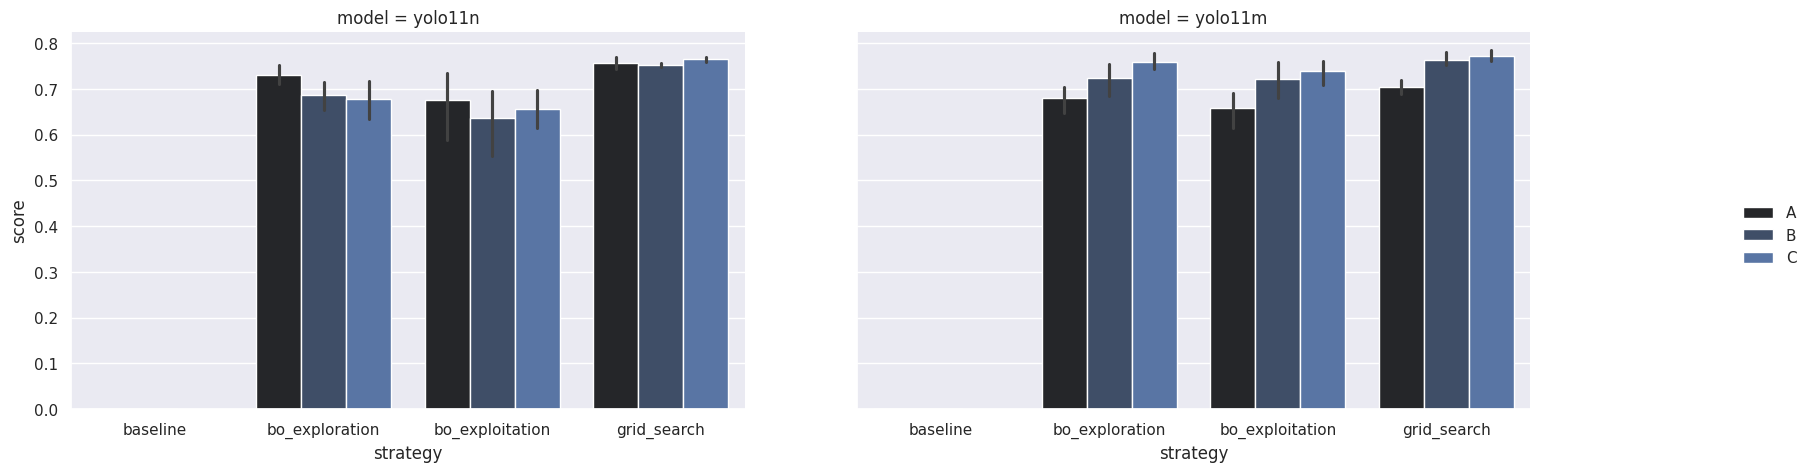

In [21]:
sns.set("notebook")
strategy_order = ["grid_search", 
                  "bo_exploration", 
                  "bo_exploitation",
                  ]
ft_order = ["1_NOFT", "2_FT"]
model_order = ["yolo11n", "yolo11m"]
cat_order = ["A", "B", "C"]
g = sns.FacetGrid(
    data_fig.query("metric == 'f1'"),
    col="model",
    col_order=model_order,
    margin_titles=True,
    sharey=True,
)
g.map_dataframe(sns.barplot, 
    x="strategy", 
    y="score", 
    hue="cat",
    hue_order=cat_order,
    # hue="strategy", style="strategy",
    # hue_order=strategy_order,
    # style_order=strategy_order,
    # err_style="band", errorbar=("sd", 1),
    # markers=True,
    # palette=["Grey", "#FF1F5B", "#00B000", "#009ADE", "#AF58BA"],
    )
# title
# g.figure.suptitle("Model Generalization in each Data Configuration")
# g.set(
#     xscale="log",
#     xticks=[2**i for i in range(6, 11)],
#     xticklabels=[2**i for i in range(6, 11)],
#     xlabel="Number of training images (n)",)
g.figure.subplots_adjust(right=1.2)
g.add_legend()
g.figure.set_size_inches(20, 6)
g.savefig(Path("out") / "results_study2.png", dpi=300)


In [ ]:
data_grid = data.loc[:, ["model", "is_finetune", "metric", "map50", "divider", "overlap", "strategy"]].query("model == 'yolo11m' and strategy in ['bo_exploration', 'bo_exploitation']")
data_grid = data_grid.query("metric == 'count' and is_finetune == '2_FT'")
data_grid

,model,metric,map50,divider,overlap,strategy
8,yolo11m,count,0.6581,3.0,0.46,bo_exploration
9,yolo11m,count,0.6632,3.0,0.10,bo_exploitation
12,yolo11m,count,0.7380,3.0,0.32,bo_exploration
13,yolo11m,count,0.6018,2.0,0.43,bo_exploitation
8,yolo11m,count,0.7436,4.0,0.11,bo_exploration
9,yolo11m,count,0.5926,2.0,0.50,bo_exploitation
12,yolo11m,count,0.7986,3.0,0.40,bo_exploration
13,yolo11m,count,0.7997,3.0,0.45,bo_exploitation
8,yolo11m,count,0.5096,2.0,0.47,bo_exploration
9,yolo11m,count,0.6447,3.0,0.41,bo_exploitation


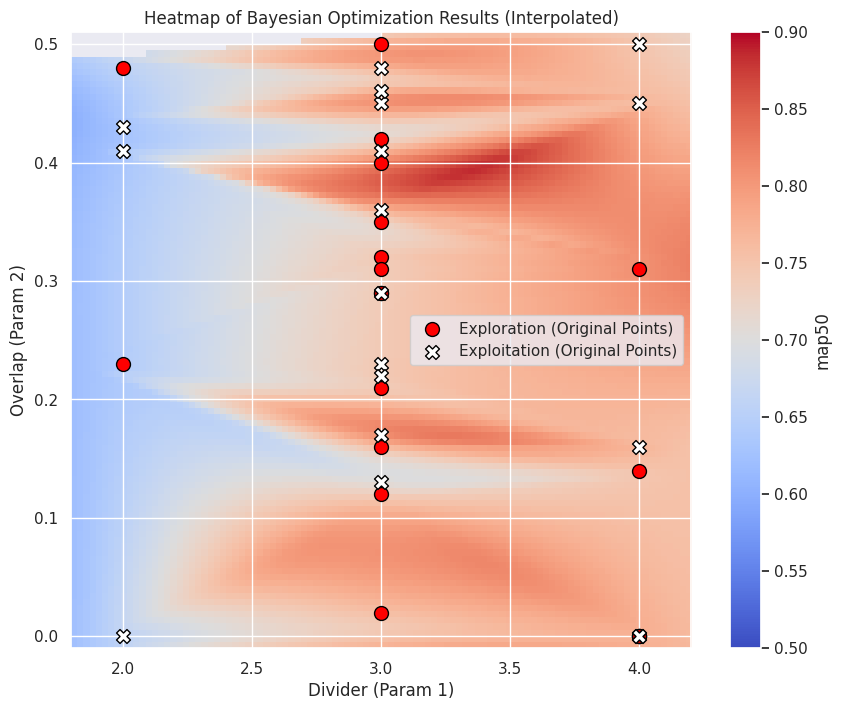

In [74]:
from scipy.interpolate import griddata
data_grid = data.loc[:, ["model", "is_finetune", "metric", "map50", "divider", "overlap", "strategy"]].\
    query("model == 'yolo11m' and strategy in ['bo_exploration', 'bo_exploitation']").\
    query("is_finetune == '2_FT'")

# Prepare data for interpolation
x = data_grid["divider"].values
y = data_grid["overlap"].values
z = data_grid["map50"].values
s = data_grid["strategy"].values

# Create a regular grid for interpolation
grid_x, grid_y = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]

# Interpolate the data
grid_z = griddata((x, y), z, (grid_x, grid_y), method="cubic")

# Plotting the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(
    grid_z.T,
    # extent=(min(x), max(x), min(y), max(y)),
    extent=(1.8, 4.2, -0.01, 0.51),
    origin="lower",
    aspect="auto",
    cmap="coolwarm",
)
plt.colorbar(label="map50")
# set uplimits of hue
plt.clim(0.5, 0.9)
plt.xlabel("Divider (Param 1)")
plt.ylabel("Overlap (Param 2)")
plt.title("Heatmap of Bayesian Optimization Results (Interpolated)")

df_exploration = data_grid[data_grid["strategy"] == "bo_exploration"]
df_exploitation = data_grid[data_grid["strategy"] == "bo_exploitation"]
plt.scatter(df_exploration["divider"], df_exploration["overlap"],
            color="red", marker="o", label="Exploration (Original Points)", s=100, edgecolors='black')
plt.scatter(df_exploitation["divider"], df_exploitation["overlap"],
            color="white", marker="X", label="Exploitation (Original Points)", s=100, edgecolors='black')
plt.legend()
plt.show()

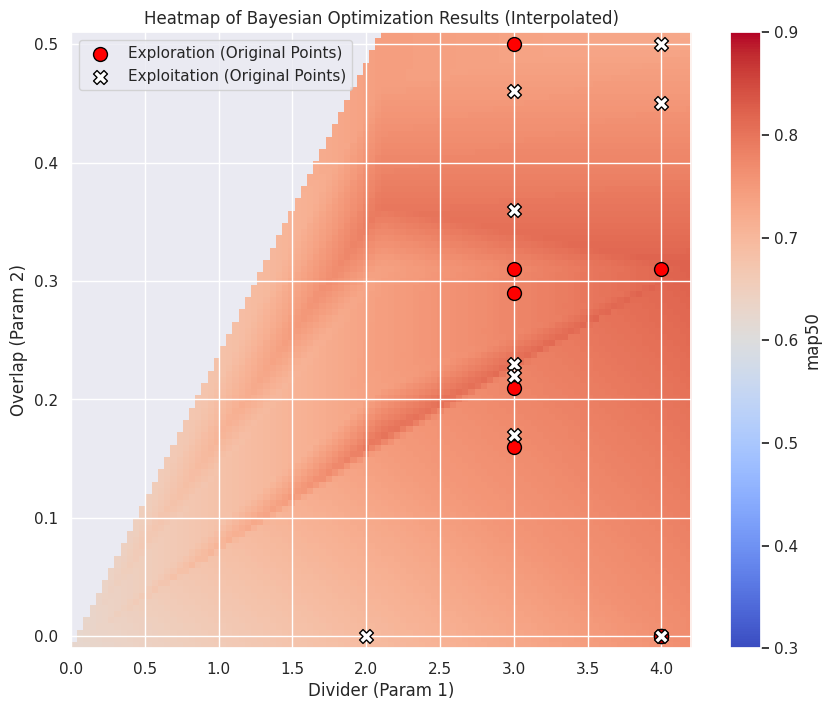

In [65]:
from scipy.interpolate import griddata
data_grid = data.loc[:, ["model", "is_finetune", "metric", "map50", "divider", "overlap", "strategy"]].query("model == 'yolo11m' and strategy in ['bo_exploration', 'bo_exploitation']")
data_grid = data_grid.query("metric == 'map' and is_finetune == '2_FT'")

# Prepare data for interpolation
x = data_grid["divider"].values
y = data_grid["overlap"].values
z = data_grid["map50"].values
s = data_grid["strategy"].values

# Create a regular grid for interpolation
grid_x, grid_y = np.mgrid[min(x):max(x):100j, min(y):max(y):100j]

# Interpolate the data
grid_z = griddata((x, y), z, (grid_x, grid_y), method="linear")

# Plotting the heatmap
plt.figure(figsize=(10, 8))
plt.imshow(
    grid_z.T,
    # extent=(min(x), max(x), min(y), max(y)),
    extent=(0, 4.2, -0.01, 0.51),
    origin="lower",
    aspect="auto",
    cmap="coolwarm",
)
plt.colorbar(label="map50")
# set uplimits of hue
plt.clim(0.3, 0.9)
plt.xlabel("Divider (Param 1)")
plt.ylabel("Overlap (Param 2)")
plt.title("Heatmap of Bayesian Optimization Results (Interpolated)")

df_exploration = data_grid[data_grid["strategy"] == "bo_exploration"]
df_exploitation = data_grid[data_grid["strategy"] == "bo_exploitation"]

plt.scatter(df_exploration["divider"], df_exploration["overlap"],
            color="red", marker="o", label="Exploration (Original Points)", s=100, edgecolors='black')
plt.scatter(df_exploitation["divider"], df_exploitation["overlap"],
            color="white", marker="X", label="Exploitation (Original Points)", s=100, edgecolors='black')
plt.legend()
plt.show()

## Study 2

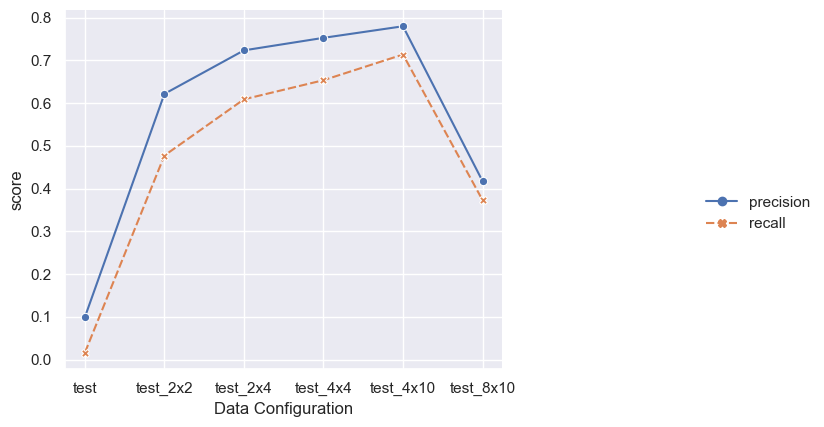

In [8]:
data_s2 = data_fig.\
        query("study == 2").\
        query("metric in ['precision', 'recall']").\
            query("model == 'yolov8n'")
# lineplot
# x: split (test, test_2x2, test_2x4, test_4x4, test_4x10, test_8x10)
# y: score
# hue: model
# style: model
# facet_grid: metric
sns.set("notebook")
g = sns.FacetGrid(
    data_s2,
    margin_titles=True,
    sharey=False,
)
g.map_dataframe(sns.lineplot,
    x="split", y="score",
    hue="metric", style="metric",
    err_style="band", errorbar=("se", 2),
    markers=True,
    # palette=["Grey", "#FF1F5B", "#00B000", "#009ADE", "#AF58BA"],
    )
# title
g.set(xlabel="Data Configuration",)

g.add_legend()
g.figure.set_size_inches(10, 5)
# dpi
g.savefig(os.path.join(DIR_SRC, "out", "conf25", "results_study2_conf25.png"), dpi=300)
